# **Module 1: Data Preprocessing and Exploration**

**Step 1: Load the Data
Decide on the Subset:**


For a first experiment, using the MQTT data (from WiFi_and_MQTT) is acceptable if it is representative and contains both benign and attack traffic.

Later, we can compare with other protocols.


Load the Data from CSV Files:


Read the CSV files from the MQTT subdirectory.


Concatenate if there are multiple CSVs.

In [ ]:
import os
import pandas as pd
from glob import glob

# If using Google Colab, mount your drive
from google.colab import drive

In [ ]:
c
# Define the path for MQTT attack data (adjust the path as needed)
mqtt_attack_path = "/content/drive/MyDrive/CICIoMT2024/test"

# Print the files in the directory to check if any CSV files exist
print(f"Files in {mqtt_attack_path}:", os.listdir(mqtt_attack_path))

# Get list of CSV files in the MQTT attack directory
csv_files = glob(os.path.join(mqtt_attack_path, "*.csv"))  # Adjust the glob pattern if needed

# Read and concatenate all CSV files into one DataFrame
# If csv_files is empty, pd.concat will raise the ValueError.
# You can add a check here and handle the case where no files are found.
if csv_files:
  df_mqtt_attack = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
else:
  print(f"No CSV files found in {mqtt_attack_path}. Please verify the path and file names.")
  df_mqtt_attack = pd.DataFrame()  # Create an empty DataFrame to avoid further errors


# Load the profiling (normal) data (assume it is in a similar directory)
profiling_path = "/content/drive/MyDrive/CICIoMT2024/profiling"
# Print the files in the profiling directory

print(f"Files in {profiling_path}:", os.listdir(profiling_path))

csv_files_profiling = glob(os.path.join(profiling_path, "*.csv"))
# Similar check for profiling files
if csv_files_profiling:
   df_mqtt_profiling = pd.concat([pd.read_csv(f) for f in csv_files_profiling], ignore_index=True)
else:
   print(f"No CSV files found in {profiling_path}. Please verify the path and file names.")
   df_mqtt_profiling = pd.DataFrame() # Create an empty DataFrame

print("MQTT Attack Data Shape:", df_mqtt_attack.shape)
print("MQTT Profiling Data Shape:", df_mqtt_profiling.shape)

Mounted at /content/drive
Files in /content/drive/MyDrive/CICIoMT2024/test: ['ARP_Spoofing_test.pcap.csv', 'Benign_test.pcap.csv', 'MQTT-DDoS-Connect_Flood_test.pcap.csv', 'MQTT-DDoS-Publish_Flood_test.pcap.csv', 'MQTT-DoS-Connect_Flood_test.pcap.csv', 'MQTT-DoS-Publish_Flood_test.pcap.csv', 'MQTT-Malformed_Data_test.pcap.csv', 'Recon-OS_Scan_test.pcap.csv', 'Recon-Ping_Sweep_test.pcap.csv', 'Recon-Port_Scan_test.pcap.csv', 'Recon-VulScan_test.pcap.csv', 'TCP_IP-DDoS-ICMP1_test.pcap.csv', 'TCP_IP-DDoS-ICMP2_test.pcap.csv', 'TCP_IP-DDoS-SYN_test.pcap.csv', 'TCP_IP-DDoS-TCP_test.pcap.csv', 'TCP_IP-DDoS-UDP1_test.pcap.csv', 'TCP_IP-DDoS-UDP2_test.pcap.csv', 'TCP_IP-DoS-ICMP_test.pcap.csv', 'TCP_IP-DoS-SYN_test.pcap.csv', 'TCP_IP-DoS-TCP_test.pcap.csv', 'TCP_IP-DoS-UDP_test.pcap.csv']
Files in /content/drive/MyDrive/CICIoMT2024/profiling: ['Idle.pcap.csv', 'Active.pcap.csv', 'ActiveBroker.pcap.csv', 'Blink_Camera_LAN_MIC.pcap.csv', 'Blink_Camera_LAN_WATCH.pcap.csv', 'Blink_Camera_WAN_MIC.p

**Step 2: Inspect and Clean the Data
Check Columns and Data Types:**


Print out column names and basic info.


Align DataFrames:


Ensure that both profiling and attack data have the same features.


Use reindex to fill missing columns with a default value (e.g., 0).

In [ ]:
# Check columns
print("Profiling Columns:", list(df_mqtt_profiling.columns))
print("Attack Columns:", list(df_mqtt_attack.columns))

# Find differences between the two DataFrames
missing_in_attack = set(df_mqtt_profiling.columns) - set(df_mqtt_attack.columns)
extra_in_attack = set(df_mqtt_attack.columns) - set(df_mqtt_profiling.columns)
print("Missing in Attack Data:", missing_in_attack)
print("Extra in Attack Data:", extra_in_attack)

# Align the attack data to have the same columns as profiling data
df_mqtt_attack = df_mqtt_attack.reindex(columns=df_mqtt_profiling.columns, fill_value=0)


Profiling Columns: ['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance']
Attack Columns: ['Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight']
Missing in Attack Data: {'T

**Step 3: Visualize Data and Check Statistics
Summary Statistics:**


Use df.describe() to get the mean, std, min, max, etc.


Plot Histograms and Distributions:

Plot histograms for key features (e.g., Header-Length, Protocol Type) to understand their distributions.


Compare Profiling vs. Attack Data:


Overlap histograms can help you visualize how different the two datasets are.

Profiling Data Summary:
       Header_Length  Protocol Type   Time_To_Live          Rate  \
count  389956.000000  389956.000000  389956.000000  3.899560e+05   
mean       24.443621       8.458800      76.846594           inf   
std         9.678853       4.727046      36.472773           NaN   
min         0.000000       0.000000       0.000000  1.946202e-05   
25%        16.000000       6.000000      64.000000  9.999471e+00   
50%        32.000000       6.000000      64.000000  5.601005e+01   
75%        32.000000       6.000000      64.000000  1.540891e+04   
max        60.000000      17.000000     255.000000           inf   

       fin_flag_number  syn_flag_number  rst_flag_number  psh_flag_number  \
count    389956.000000    389956.000000    389956.000000    389956.000000   
mean          0.004641         0.005123         0.002950         0.337740   
std           0.025479         0.027991         0.027723         0.265311   
min           0.000000         0.000000         0.00000

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


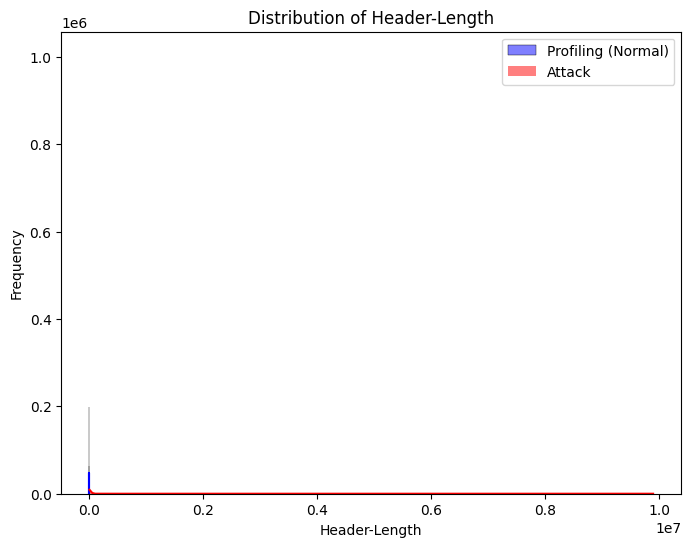

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Summary statistics
print("Profiling Data Summary:")
print(df_mqtt_profiling.describe())
print("\nAttack Data Summary:")

print(df_mqtt_attack.describe())

# Visualize distribution of a key feature (e.g., Header-Length)
plt.figure(figsize=(8, 6))
sns.histplot(df_mqtt_profiling['Header_Length'], kde=True, color='blue', label='Profiling (Normal)')
sns.histplot(df_mqtt_attack['Header_Length'], kde=True, color='red', label='Attack')
plt.xlabel("Header-Length")
plt.ylabel("Frequency")
plt.title("Distribution of Header-Length")
plt.legend()
plt.show()

# Afficher un aperçu des données




# You can repeat similar plots for other important features.


Profiling Data Summary:
       Header_Length  Protocol Type   Time_To_Live          Rate  \
count  389956.000000  389956.000000  389956.000000  3.899560e+05   
mean       24.443621       8.458800      76.846594           inf   
std         9.678853       4.727046      36.472773           NaN   
min         0.000000       0.000000       0.000000  1.946202e-05   
25%        16.000000       6.000000      64.000000  9.999471e+00   
50%        32.000000       6.000000      64.000000  5.601005e+01   
75%        32.000000       6.000000      64.000000  1.540891e+04   
max        60.000000      17.000000     255.000000           inf   

       fin_flag_number  syn_flag_number  rst_flag_number  psh_flag_number  \
count    389956.000000    389956.000000    389956.000000    389956.000000   
mean          0.004641         0.005123         0.002950         0.337740   
std           0.025479         0.027991         0.027723         0.265311   
min           0.000000         0.000000         0.00000

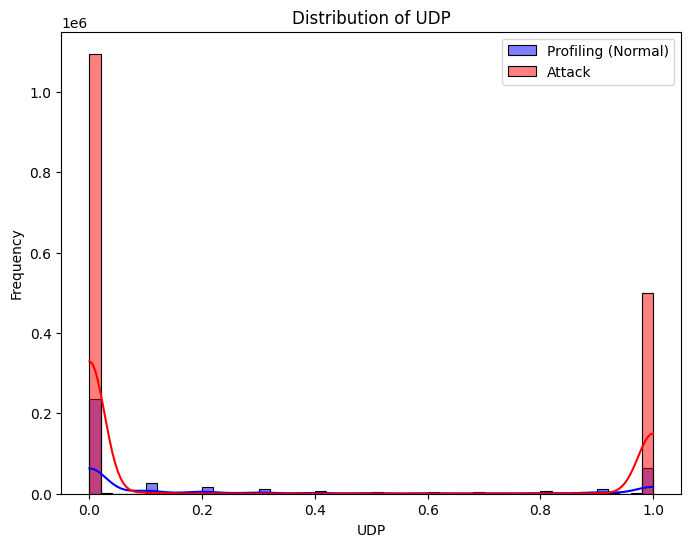

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Summary statistics
print("Profiling Data Summary:")
print(df_mqtt_profiling.describe())
print("\nAttack Data Summary:")
print(df_mqtt_attack.describe())

# Visualize distribution of a key feature (e.g., Header-Length)
plt.figure(figsize=(8, 6))
sns.histplot(df_mqtt_profiling['UDP'], bins=50, kde=True, color='blue', label='Profiling (Normal)')
sns.histplot(df_mqtt_attack['UDP'], bins=50, kde=True, color='red', label='Attack')
plt.xlabel("UDP")
plt.ylabel("Frequency")
plt.title("Distribution of UDP")
plt.legend()
plt.show()

# You can repeat similar plots for other important features.


**Step 4: Normalization
Standardize the Data:**

Use StandardScaler to fit on the
profiling (normal) data.


Transform both profiling and attack data with the same scaler.

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

#Remplacer les valeurs infinies par des valeurs finies
df_mqtt_profiling.replace([np.inf, -np.inf], np.nan, inplace=True)
df_mqtt_profiling.fillna(df_mqtt_profiling.mean(), inplace=True)  # Remplace les NaN par la moyenne des colonnes

scaler = StandardScaler()
df_mqtt_profiling_scaled = scaler.fit_transform(df_mqtt_profiling)
df_mqtt_attack_scaled = scaler.transform(df_mqtt_attack)

# Convert scaled arrays back to DataFrames (optional)
df_mqtt_profiling_scaled = pd.DataFrame(df_mqtt_profiling_scaled, columns=df_mqtt_profiling.columns)
df_mqtt_attack_scaled = pd.DataFrame(df_mqtt_attack_scaled, columns=df_mqtt_attack.columns)

print("Data normalization complete.")


Data normalization complete.


**Step 5: Save Your Clean and Normalized Data**

Save to CSV or Numpy files:

In [ ]:
df_mqtt_profiling_scaled.to_csv("/content/drive/MyDrive/zeroday_detection/data/df_mqtt_profiling_scaled.csv", index=False)
df_mqtt_attack_scaled.to_csv("/content/drive/MyDrive/zeroday_detection/data/df_mqtt_attack_scaled.csv", index=False)
print("Normalized data saved successfully.")


Normalized data saved successfully.
